In [8]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

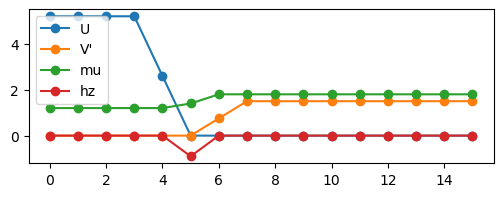

In [9]:
widthS = 5
widthF = 1
widthP = 10

X, Y = widthS+widthF+widthP, 101
lattice = Lattice(X, Y)

t = 1
T = 0.1

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS + widthF] = muF
mu[widthS + widthF:] = muP

h0 = -0.9 * t
h = np.zeros_like(mu)
h[widthS:widthS + widthF] = h0

V = None

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthS] = 0
V_prime[widthF+widthS] = V_prime0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

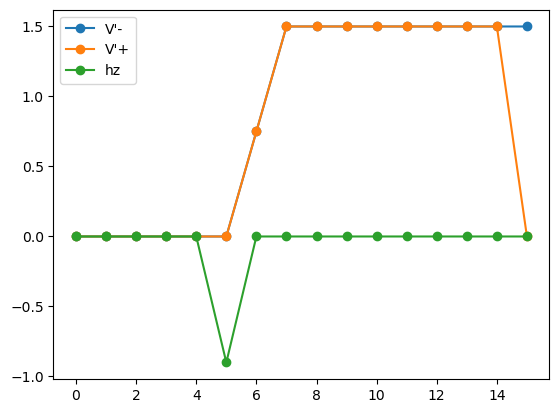

In [10]:
# V_plus = np.r_[V[:-1], [0]]
# V_minus = np.r_[[0], V[1:]]
Vprime_plus = np.r_[V_prime[:-1], [0]]
Vprime_minus = np.r_[[0], V_prime[1:]]

plt.plot(Vprime_minus, "-o", label="V'-")
plt.plot(Vprime_plus, "-o", label="V'+")
# plt.plot(V_minus, "-o", label="V-")
# plt.plot(V_plus, "-o", label="V+")
plt.plot(h, '-o', label='hz')
plt.legend()

In [11]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime,
                F0_init=0.5,
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hx=h)

In [12]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.6420398206314102
Relative error: 75619649201.99527
Average old: (0.15625+0j)
Average: (0.24972246158823902+0j)
F_xplus:
Absolute error: 0.1286885632950532
Relative error: 128688563295.05322
Average old: 0j
Average: (-0.02007941528080454+0j)
F_xmin:
Absolute error: 0.1288778373013362
Relative error: 128877837301.33621
Average old: 0j
Average: (-0.020846324592103515+0j)
F_yplus:
Absolute error: 0.1520756702952499
Relative error: 152075670295.24988
Average old: 0j
Average: (-0.023270280063287622+0.00020478306413935674j)
F_ymin:
Absolute error: 0.1520756702952499
Relative error: 152075670295.24988
Average old: 0j
Average: (-0.023270280063287622-0.00020478306413935674j)
Fuu_xplus:
Absolute error: 0.0716840269662676
Relative error: 42480521755.57859
Average old: (0.06+0j)
Average: (0.05485234224170212+0j)
Fuu_xmin:
Absolute error: 0.129681165716941
Relative error: 41592378242.32201
Average old: (-0.06666666666666667+0j)
Average: (-0.054869964284545464+0j)
Fuu_yplus:
Abs

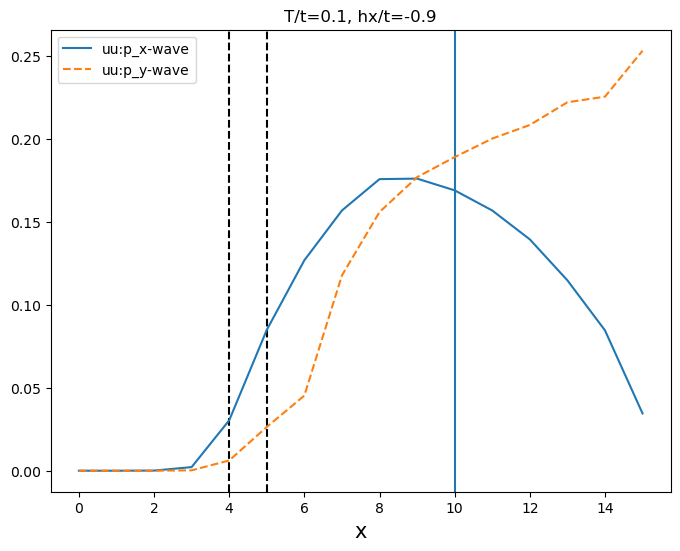

In [16]:
x = np.arange(0, widthS + widthF + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hx/t={h0}")
axs.axvline(int(widthS)-1, color='black', linestyle='--')
axs.axvline(widthS+widthF-1, color='black', linestyle='--')
axs.axvline(11-1)

# axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
# axs.plot(x, np.imag(F.dwave), label="Im(F.dwave)")
# axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
# axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
# axs.plot(x, np.abs(H.F0), label="onsite: s")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_ylim(None, 1)
axs.legend()
plt.show()

In [49]:
print(H.converged)

True


In [50]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.30 + 1e-12, 0.01),
    np.arange(0.31, 0.60 + 1e-12, 0.002)
])
print(len(temps))

185


In [51]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.30 + 1e-12, 0.01),
    np.arange(0.31, 0.41 + 1e-12, 0.001),
    np.arange(0.42, 0.60 + 1e-12, 0.002)
])  # 231 temps total
print(len(temps))

231
